In [1]:
import os
import glob
import tomllib
import numpy as np
import matplotlib.pyplot as plt
from astropy.visualization import ImageNormalize, LogStretch
from astropy.table import Table
from astropy.wcs import WCS
from astropy.io import fits



In [2]:
def get_path_to_file(wdir, version, project, galaxy, ptype):
     """Get the path to the data file based on the version, project, galaxy, product type, and filter.
     Args:
          version: version of the data (e.g., v4p1)
          project: JWST PID (e.g., 4793)
          galaxy: galaxy name 
          ptype: product type (e.g., images (for anchored), features, psfmatch, etc.)
          filter: filter name."""
     # TODO: Add functionality for files not in the release directory
     path = f"{wdir}{version}/{project}/release/{galaxy}/{ptype}/"

     # Check that the path exists
     if os.path.exists(path):
          print(f"Found file for {galaxy} {filter} in {path}")
     else:
          raise FileNotFoundError(f"No file found for {galaxy} {filter} in {path}. Please check the path and file naming conventions.")
     return path


def load_catalog(path, filename, **kwargs):
    """Load the catalog as an astropy Table."""
    return Table.read(f"{path}/{filename}")

In [3]:
# ------------------------------------------------------------------------------
# Making source cutouts
#-------------------------------------------------------------------------------

def make_cutout(row, radius, img_sub):
    """Make a cutout of the image centered on the given coordinates."""
    x, y = row['x_center'], row['y_center']
    cutout_size = radius * 5
    x_min, x_max = int(x - cutout_size), int(x + cutout_size)
    y_min, y_max = int(y - cutout_size), int(y + cutout_size)
    img_cutout = img_sub[y_min:y_max, x_min:x_max]
    return img_cutout, cutout_size


def make_source_profile(cutout):
    """Make a line plot of the source profile in the cutout."""
    mid_x = cutout.shape[1] // 2
    mid_y = cutout.shape[0] // 2
    x_profile = cutout[mid_y, :]
    y_profile = cutout[:, mid_x]
    return x_profile, y_profile


def plot_annuli(ax, x, y, radius, sky_in, sky_out):
    """Plot the optimal aperture radius and sky annulus on a cutout."""
    # Draw a circle with radius equal to the optimal aperture radius
    circle = plt.Circle((x, y), radius, edgecolor='red', facecolor='none', lw=1.5, alpha=1.0)
    sky_in_circle = plt.Circle((x, y), sky_in, edgecolor='magenta', facecolor='none', lw=1.5, alpha=0.5)
    sky_out_circle = plt.Circle((x, y), sky_out, edgecolor='orange', facecolor='none', lw=1.5, alpha=0.5)  
    ax.add_patch(circle)
    ax.add_patch(sky_in_circle)
    ax.add_patch(sky_out_circle)
    return

In [5]:
# Load the config file
config_file = '../config/config.toml'     # Photometry parameters
local_file = '../config/local.toml'       # Paths to directories

def load_config(config_path: str) -> dict:
    with open(config_path, "rb") as f:
        return tomllib.load(f)

# Unpack the parameters from the config file
conf = load_config(config_file)
local = load_config(local_file)

# Get top level parameters
steps   = conf['steps']
targets = conf['targets']
bands   = conf['bands']
projects = conf['projects']
product = conf['product']
version = conf['version']
ptype = conf['ptype']
band = bands[0]  # Assuming we are working with the first band for now

Load in the tables and the relevant images.

In [6]:
# Load the catalog
merged_table = load_catalog(local['out_dir'], f"{targets[0]}_jwst_{bands[0]}_cat.fits")
# radius = conf['parameters']['photometry']['aperture_radius']
# sky_in = conf['parameters']['photometry']['radius_sky_in']
# sky_out = conf['parameters']['photometry']['radius_sky_out']

filename = glob.glob(f"{local['jwst_dir']}{version}/{projects[0]}/release/{targets[0]}/images/*{bands[0].lower()}*")[0]
with fits.open(filename) as hdul:
    img_sub = hdul['SCI'].data
    header = hdul['SCI'].header


# Alternative approach using standardised aperture corrections from the JWST CRDS.
path_to_crds = "/nexus/posix0/MIA-astro-env/eschinner/jgonzalez/jwst_pipeline/crds_cache/jwst_ops/references/jwst/" + 'nircam' + "/"

# Get the apcorr file using glob
apcorr_files = glob.glob(path_to_crds + f"*apcorr*")
apcorr_data = fits.getdata(apcorr_files[0], ext=1)

# Get data for a specific eefraction
eefraction_value = 0.70
eefraction_full = 0.9
row = apcorr_data[apcorr_data['eefraction'] == eefraction_value]
row_full = apcorr_data[apcorr_data['eefraction'] == eefraction_full]

# Limit to a specific filter 
row = row[(row['filter'] == band.upper())]
row_full = row_full[(row_full['filter'] == band.upper())]
radius_full = row_full['radius'][0]  # in pixels
# Extract values
wcs_apcorr = WCS(header)
radius = row['radius'][0]   # in pixels
sky_in = row['skyin'][0]    # in pixels
sky_out = row['skyout'][0]  # in pixels
apcorr = row['apcorr'][0]   # factor to multiply enclosed flux to get total flux

Set OBSGEO-B to    19.380569 from OBSGEO-[XYZ].
Set OBSGEO-H to 1225175032.538 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]


In [7]:
print(merged_table.colnames)

['id', 'x_center', 'y_center', 'aperture_sum', 'flux', 'sharpness', 'roundness', 'finder_mag', 'peak', 'ra', 'dec', 'finder_flux_abmag', 'aperture_sum_abmag']


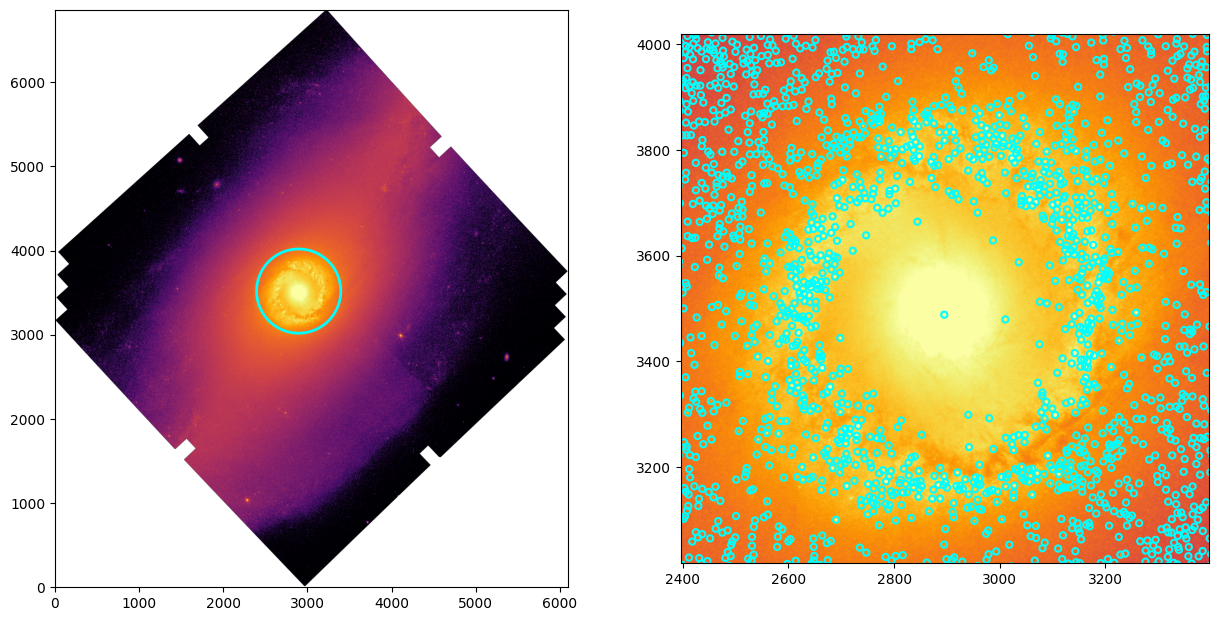

In [8]:
# Select only sources in the galaxy center (i.e. within a radius of 500 pixels from the central pixel of the image)
bright_sources = merged_table[np.where(merged_table['aperture_sum_abmag'] < 30)]

# And the mosaic with these sources highlighted
fig, ax = plt.subplots(1, 2, figsize=(15, 7.5))
norm_mosaic = ImageNormalize(vmin=np.nanpercentile(img_sub, 25.00), 
                            vmax=np.nanpercentile(img_sub, 99.9),
                            stretch=LogStretch())
ax[0].imshow(img_sub, origin='lower', cmap='inferno', norm=norm_mosaic)
# Plot a circle of radius 200 pixels separating the galactic center
circle = plt.Circle((wcs_apcorr.wcs.crpix[0]-150, 
                     wcs_apcorr.wcs.crpix[1]+80), 
                     500, 
                     edgecolor='cyan', 
                     facecolor='none', 
                     lw=2)
ax[0].add_patch(circle)

# Zoom in
ax[1].imshow(img_sub, origin='lower', cmap='inferno', norm=norm_mosaic)
size = 500
centre_mosaic_x = wcs_apcorr.wcs.crpix[0]-150
centre_mosaic_y = wcs_apcorr.wcs.crpix[1]+80
ax[1].set_xlim(centre_mosaic_x-size, centre_mosaic_x+size)
ax[1].set_ylim(centre_mosaic_y-size, centre_mosaic_y+size)
# Plot all sources in the aperture-corrected catalog
ax[1].scatter(bright_sources['x_center'], bright_sources['y_center'], s=20, edgecolor='cyan', facecolor='none', lw=1.5, label='Sources in aperture-corrected catalog')
# for i in range(len(galaxy_center_sources)):
    # ax[1].scatter(galaxy_center_sources['x_center'][i], 
    #                galaxy_center_sources['y_center'][i], 
    #                s=100, edgecolor='cyan', facecolor='none', lw=2, label='Sources in galaxy center' if i==0 else "")
    # ax[1].text(galaxy_center_sources['x_center'][i], 
    #            galaxy_center_sources['y_center'][i]+105, 
    #            f"{i+1}", color='cyan', fontsize=10, ha='center', va='center')
plt.show()

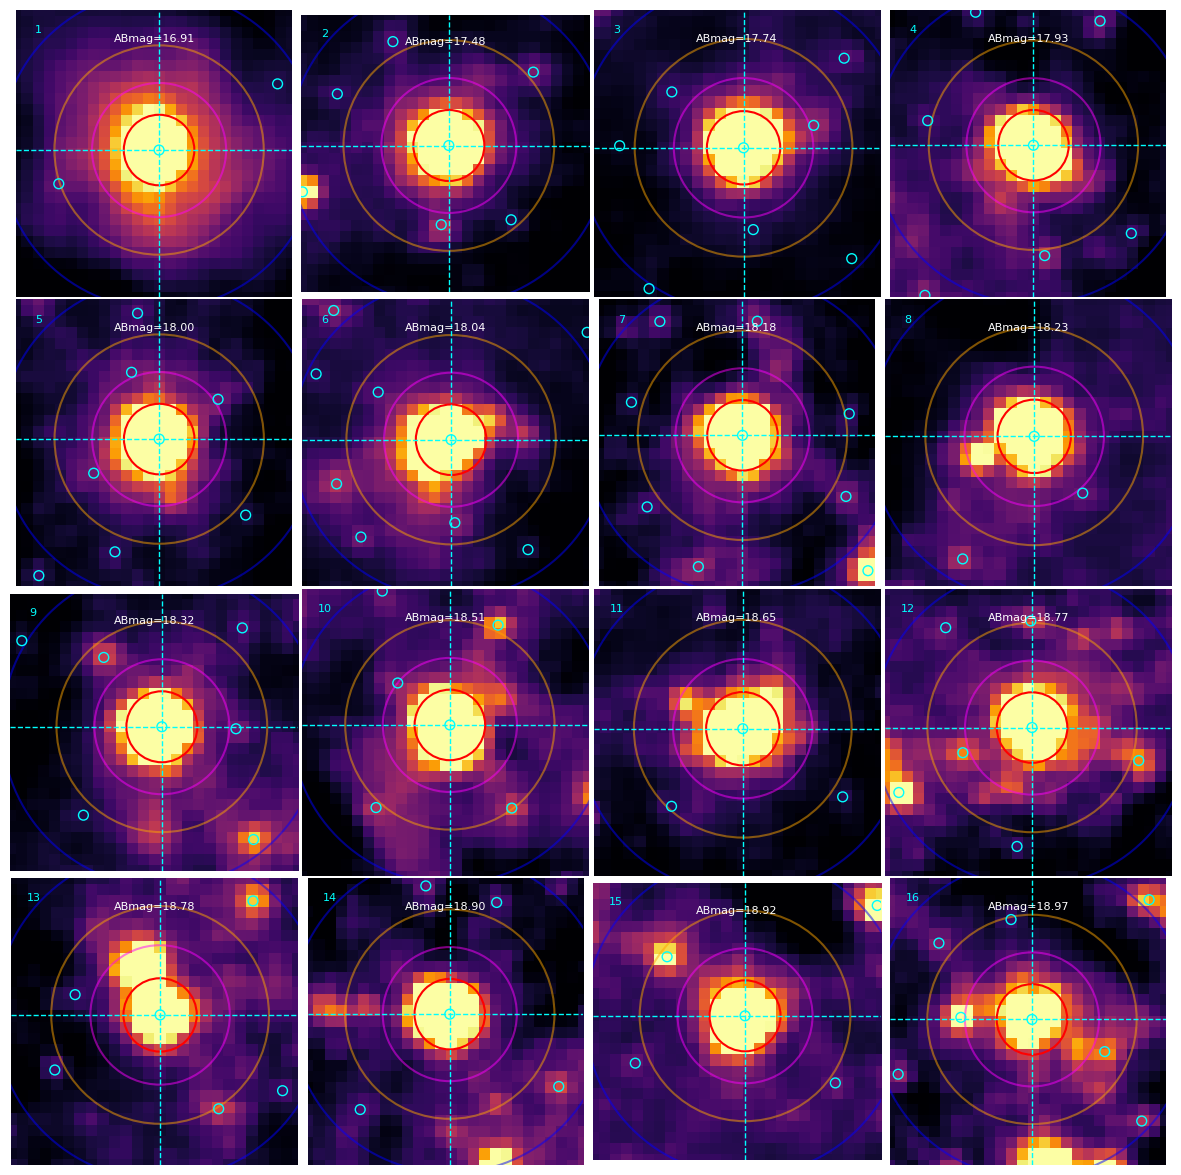

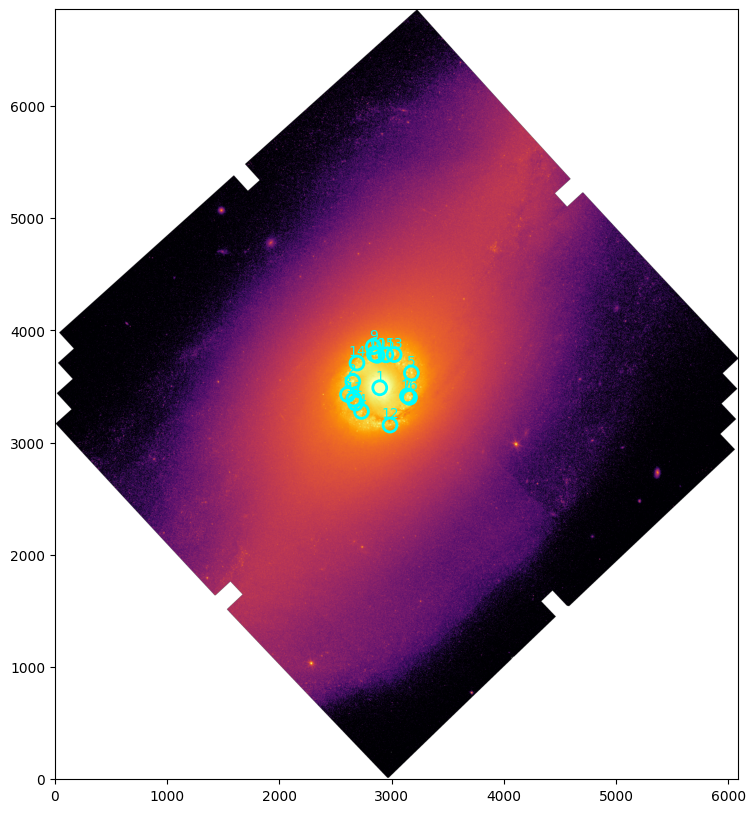

In [ ]:
# Select only sources in the galaxy center (i.e. within a radius of 500 pixels from the central pixel of the image)
galaxy_center_sources = merged_table[np.where((merged_table['x_center'] - img_sub.shape[1]/2)**2 + (merged_table['y_center'] - img_sub.shape[0]/2)**2 < 500**2)]

# Make the 6x6 plot of source cutouts using sources from the aperture corrected catalog
brightest_sources_apcorr = galaxy_center_sources[:16]#np.argsort(merged_table['aperture_sum_abmag'])][:16]
fig, axes = plt.subplots(4, 4, figsize=(15, 15), gridspec_kw={'wspace': 0.01, 'hspace': 0.01})
for i, (ax, row) in enumerate(zip(axes.flatten(), brightest_sources_apcorr)):
    x, y = row['x_center'], row['y_center']
    cutout_size = radius*4
    x_min, x_max = int(x - cutout_size), int(x + cutout_size)
    y_min, y_max = int(y - cutout_size), int(y + cutout_size)
    cutout = img_sub[y_min:y_max, x_min:x_max]
    norm_cutout = ImageNormalize(vmin=np.nanpercentile(cutout, 5), 
                                vmax=np.nanpercentile(cutout, 95))
    ax.imshow(img_sub, origin='lower', cmap='inferno', norm=norm_cutout)
    # Plot horizontal and vertical lines through the center of the cutout
    ax.axhline(y, color='cyan', ls='--', lw=1.0)
    ax.axvline(x, color='cyan', ls='--', lw=1.0)
    # Draw a circle with radius equal to the optimal aperture radius
    circle = plt.Circle((x, y), radius, edgecolor='red', facecolor='none', lw=1.5, alpha=1.0)
    sky_in_circle = plt.Circle((x, y), sky_in, edgecolor='magenta', facecolor='none', lw=1.5, alpha=0.5)
    sky_out_circle = plt.Circle((x, y), sky_out, edgecolor='orange', facecolor='none', lw=1.5, alpha=0.5)  
    eefull_circle = plt.Circle((x, y), radius_full, edgecolor='blue', facecolor='none', lw=1.5, alpha=0.5)
    ax.add_patch(circle)
    ax.add_patch(sky_in_circle)
    ax.add_patch(sky_out_circle)
    ax.add_patch(eefull_circle)
    ax.axis('off')
    ax.set_xlim(x_min, x_max)
    ax.set_ylim(y_min, y_max)
    ax.text(0.5, 0.9, f"ABmag={row['aperture_sum_abmag']:.2f}", color='white', fontsize=8, ha='center', va='center', transform=ax.transAxes)
    ax.text(0.08, 0.93, f"{i+1}", color='cyan', fontsize=8, ha='center', va='center', transform=ax.transAxes)
    # Select all sources in the catalog that are within the cutout region
    sources_in_cutout = merged_table[(merged_table['x_center'] > x_min) & (merged_table['x_center'] < x_max) & (merged_table['y_center'] > y_min) & (merged_table['y_center'] < y_max)]
    ax.scatter(sources_in_cutout['x_center'], sources_in_cutout['y_center'], s=50, edgecolor='cyan', facecolor='none', lw=1.0)
plt.show()

# And the mosaic with these sources highlighted
fig, ax = plt.subplots(figsize=(10, 10))
norm_mosaic = ImageNormalize(vmin=np.nanpercentile(img_sub, 25.00), 
                            vmax=np.nanpercentile(img_sub, 99.9),
                            stretch=LogStretch())
ax.imshow(img_sub, origin='lower', cmap='inferno', norm=norm_mosaic)
# ax.scatter(merged_table['x_center'], merged_table['y_center'], s=20, edgecolor='cyan', facecolor='none', lw=1.5, label='Sources in aperture-corrected catalog')
for i in range(len(brightest_sources_apcorr)):
    ax.scatter(brightest_sources_apcorr['x_center'][i], 
               brightest_sources_apcorr['y_center'][i], 
               s=100, edgecolor='cyan', facecolor='none', lw=2, label='Brightest sources in aperture-corrected catalog' if i==0 else "")
    ax.text(brightest_sources_apcorr['x_center'][i], 
            brightest_sources_apcorr['y_center'][i]+105, 
            f"{i+1}", color='cyan', fontsize=10, ha='center', va='center')
plt.show()